# Lab 3 — Statistics Basics

**Day 01 · Data Science Introduction · Cisco AI/ML Training**

---

## Goals

1. Compute **mean**, **median**, **standard deviation**, **min**, **max**, and **percentiles**.
2. Mirror Excel formulas (`AVERAGE`, `MEDIAN`, `STDEV.S`, `QUARTILE`) in pandas.
3. Explain mean vs median and when each misleads executives.
4. Measure **outlier impact** (TS029) and apply the **IQR rule**.
5. Summarize sales **by region** and rank teams by **% growth**.

> **Quick check:** rows **100** · mean ≈ **1002.76** · median ≈ **705.0** · std ≈ **954.19**

**Dataset:** `data/team-sales/team_sales.csv` — complete in **Excel or this notebook**.

## Why this matters

Executives ask for **one number** to summarize performance. Mean, median, and spread answer different questions. Day 2 scaling, Day 3 classification metrics, and Day 6 fraud outliers all assume you can read a distribution.

## Descriptive statistics reference

| Measure | Plain language | Excel | pandas |
|---------|----------------|-------|--------|
| Mean | Arithmetic average | `=AVERAGE()` | `.mean()` |
| Median | Middle value when sorted | `=MEDIAN()` | `.median()` |
| Std dev (sample) | Typical spread | `=STDEV.S()` | `.std(ddof=1)` |
| Min / Max | Ends of range | `=MIN()` / `=MAX()` | `.min()` / `.max()` |
| Q1 / Q3 | 25th / 75th percentile | `=QUARTILE(...,1/3)` | `.quantile(0.25/0.58)` |

---

## 1. Load and inspect team sales

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif GH_ROOT.name == "01-data-science-introduction":
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "data" / "team-sales" / "team_sales.csv").is_file():
            GH_ROOT = parent
            break

TEAM_SALES_CSV = GH_ROOT / "data" / "team-sales" / "team_sales.csv"

import json

LAB_PROFILE = json.loads(
    (GH_ROOT / "data" / "team-sales" / "lab_profile.json").read_text(encoding="utf-8")
)
OUTLIER_TEAM = LAB_PROFILE["outlier_team_id"]
VOL_REGION = LAB_PROFILE["compare_region_volume"]
GROWTH_REGION = LAB_PROFILE["compare_region_growth"]
df = pd.read_csv(TEAM_SALES_CSV)

print(f"rows: {len(df)}")
print(f"columns: {list(df.columns)}")
print(f"regions: {sorted(df['region'].unique())}")
display(df.head(8))
display(df.tail(3))
print("\ndtypes:")
print(df.dtypes)


rows: 100
columns: ['team', 'team_name', 'region', 'state', 'product_line', 'sub_category', 'segment', 'q1_sales', 'q2_sales', 'q1_units', 'q2_units']
regions: ['Central', 'East', 'South', 'West']


,team,team_name,region,state,product_line,sub_category,segment,q1_sales,q2_sales,q1_units,q2_units
0,TS001,Chicago - Chairs,Central,Illinois,Furniture,Chairs,Home Office,934,1252,7,15
1,TS002,Chicago - Chairs,Central,Illinois,Furniture,Chairs,Consumer,528,859,5,7
2,TS003,Chicago - Furnishings,Central,Illinois,Furniture,Furnishings,Consumer,164,542,7,29
3,TS004,Chicago - Machines,Central,Illinois,Technology,Machines,Home Office,785,1008,4,3
4,TS005,Chicago - Paper,Central,Illinois,Office Supplies,Paper,Home Office,560,367,16,18
5,TS006,Chicago - Phones,Central,Illinois,Technology,Phones,Home Office,972,1272,10,6
6,TS007,Chicago - Storage,Central,Illinois,Office Supplies,Storage,Consumer,60,1473,2,13
7,TS008,Chicago - Tables,Central,Illinois,Furniture,Tables,Home Office,481,109,3,1


,team,team_name,region,state,product_line,sub_category,segment,q1_sales,q2_sales,q1_units,q2_units
97,TS098,Seattle - Storage,West,Washington,Office Supplies,Storage,Home Office,649,212,8,10
98,TS099,Seattle - Tables,West,Washington,Furniture,Tables,Corporate,4287,1769,10,10
99,TS100,Seattle - Tables,West,Washington,Furniture,Tables,Consumer,959,1387,5,10



dtypes:
team            object
team_name       object
region          object
state           object
product_line    object
sub_category    object
segment         object
q1_sales         int64
q2_sales         int64
q1_units         int64
q2_units         int64
dtype: object


### 1b. First-pass profile (`describe`)

In [2]:
profile = df.describe().round(2)
display(profile)

# Row-level scan: any missing values?
print("missing per column:")
print(df.isna().sum())


,q1_sales,q2_sales,q1_units,q2_units
count,100.00,100.00,100.00,100.00
mean,891.71,1002.76,11.47,16.67
std,960.03,954.19,9.05,14.69
min,53.00,98.00,1.00,1.00
25%,312.50,366.25,5.00,6.00
50%,581.50,705.00,10.00,14.50
75%,1033.00,1309.00,15.00,21.00
max,5158.00,5308.00,53.00,88.00


missing per column:
team            0
team_name       0
region          0
state           0
product_line    0
sub_category    0
segment         0
q1_sales        0
q2_sales        0
q1_units        0
q2_units        0
dtype: int64


---

## 2. Q2 sales — core descriptive statistics

In [3]:
q2 = df["q2_sales"]

stats = {
    "mean": q2.mean(),
    "median": q2.median(),
    "std": q2.std(ddof=1),
    "min": q2.min(),
    "max": q2.max(),
    "q1": q2.quantile(0.25),
    "q3": q2.quantile(0.58),
}

stats_df = pd.DataFrame({"measure": list(stats.keys()), "value": list(stats.values())})
display(stats_df.round(2))

print("\nExcel check (type these in a blank sheet on team_sales.csv):")
print("  =AVERAGE(E2:E101)   → mean")
print("  =MEDIAN(E2:E101)    → median")
print("  =STDEV.S(E2:E101)   → sample std")


,measure,value
0,mean,1002.76
1,median,705.00
2,std,954.19
3,min,98.00
4,max,5308.00
5,q1,366.25
6,q3,839.72



Excel check (type these in a blank sheet on team_sales.csv):
  =AVERAGE(E2:E101)   → mean
  =MEDIAN(E2:E101)    → median
  =STDEV.S(E2:E101)   → sample std


### 2b. Q1 sales — same measures (compare quarters)

In [4]:
q1 = df["q1_sales"]
compare_q = pd.DataFrame({
    "quarter": ["Q1", "Q2"],
    "mean": [q1.mean(), q2.mean()],
    "median": [q1.median(), q2.median()],
    "std": [q1.std(ddof=1), q2.std(ddof=1)],
}).round(2)
display(compare_q)
print("Did the typical team improve Q1 → Q2?", "Yes" if q2.mean() > q1.mean() else "No")


,quarter,mean,median,std
0,Q1,891.71,581.5,960.03
1,Q2,1002.76,705.0,954.19


Did the typical team improve Q1 → Q2? Yes


---

## 3. Outlier impact — TS029

In [5]:
top_team = df.loc[df["q2_sales"].idxmax()]
print(f"Highest Q2 team: {top_team['team']} ({top_team['region']}) → {int(top_team['q2_sales'])}")

mean_all = q2.mean()
mean_without = df.loc[df["team"] != "TS029", "q2_sales"].mean()
print(f"\nMean with all teams:    {mean_all:.2f}")
print(f"Mean without TS029:   {mean_without:.2f}")
print(f"Mean shift from one row: {mean_all - mean_without:.2f}")
print(f"Median (robust):         {q2.median():.2f}")


Highest Q2 team: TS029 (East) → 5308

Mean with all teams:    1002.76
Mean without TS029:   959.27
Mean shift from one row: 43.49
Median (robust):         705.00


### 3b. IQR outlier rule (links to Day 6)

In [6]:
q1_val, q3_val = q2.quantile(0.25), q2.quantile(0.58)
iqr = q3_val - q1_val
lower, upper = q1_val - 1.5 * iqr, q3_val + 1.5 * iqr
outlier_mask = (q2 < lower) | (q2 > upper)

print(f"IQR fence: [{lower:.1f}, {upper:.1f}]")
print("Teams flagged by IQR rule:")
display(df.loc[outlier_mask, ["team", "region", "q2_sales"]])


IQR fence: [-344.0, 1549.9]
Teams flagged by IQR rule:


,team,region,q2_sales
15,TS016,Central,1914
18,TS019,Central,1752
28,TS029,East,5308
30,TS031,East,1876
31,TS032,East,3037
38,TS039,East,2128
41,TS042,East,1947
48,TS049,East,2073
61,TS062,West,1713
66,TS067,West,1660


---

## 4. Visual checks

C:\Users\PC\AppData\Local\Temp\ipykernel_23352\2969815395.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="region", y="q2_sales", ax=axes[1], palette="Set2")


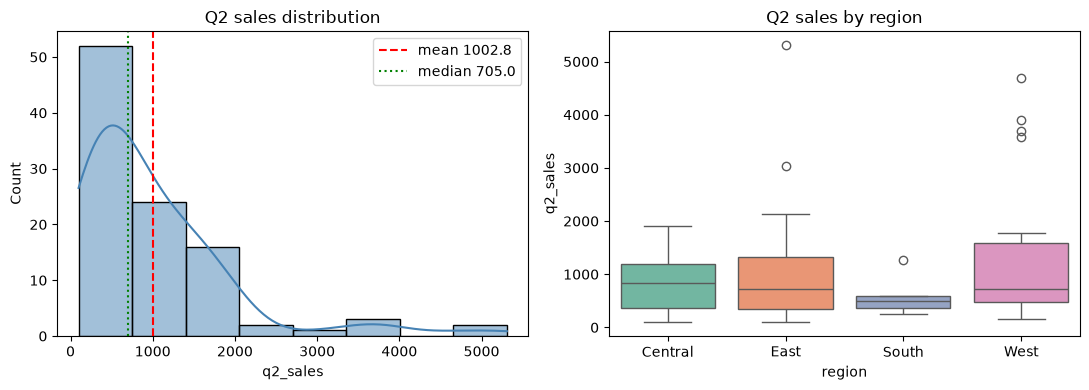

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(q2, bins=8, kde=True, ax=axes[0], color="steelblue")
axes[0].axvline(stats["mean"], color="red", linestyle="--", label=f"mean {stats['mean']:.1f}")
axes[0].axvline(stats["median"], color="green", linestyle=":", label=f"median {stats['median']:.1f}")
axes[0].set_title("Q2 sales distribution")
axes[0].legend()

sns.boxplot(data=df, x="region", y="q2_sales", ax=axes[1], palette="Set2")
axes[1].set_title("Q2 sales by region")
plt.tight_layout()
plt.show()


---

## 5. Regional aggregation

In [8]:
region = df.groupby("region").agg(
    teams=("team", "count"),
    total_q1=("q1_sales", "sum"),
    total_q2=("q2_sales", "sum"),
    avg_q2=("q2_sales", "mean"),
    median_q2=("q2_sales", "median"),
).round(2)
region["delta_q2_q1"] = region["total_q2"] - region["total_q1"]
display(region.sort_values("total_q2", ascending=False))

print("Rank by total Q2 vs rank by average Q2 — same order?")
print(region.sort_values("total_q2", ascending=False).index.tolist())
print(region.sort_values("avg_q2", ascending=False).index.tolist())


,teams,total_q1,total_q2,avg_q2,median_q2,delta_q2_q1
region,,,,,,
West,39,46476,45366,1163.23,727.0,-1110
East,32,26263,32226,1007.06,714.0,5963
Central,24,15111,19696,820.67,840.0,4585
South,5,1321,2988,597.60,504.0,1667


Rank by total Q2 vs rank by average Q2 — same order?
['West', 'East', 'Central', 'South']
['West', 'East', 'Central', 'South']


### 5b. Growth rate by team (% change Q1 → Q2)

In [9]:
df["growth_pct"] = (df["q2_sales"] - df["q1_sales"]) / df["q1_sales"]
print("Top 5 teams by % growth:")
display(df.nlargest(5, "growth_pct")[["team", "region", "q1_sales", "q2_sales", "growth_pct"]].round(3))

print("\nBottom 3 (declining Q2):")
display(df.nsmallest(3, "growth_pct")[["team", "region", "q1_sales", "q2_sales", "growth_pct"]].round(3))


Top 5 teams by % growth:


,team,region,q1_sales,q2_sales,growth_pct
93,TS094,West,97,3692,37.062
83,TS084,West,53,1642,29.981
6,TS007,Central,60,1473,23.550
56,TS057,South,60,595,8.917
67,TS068,West,185,1676,8.059



Bottom 3 (declining Q2):


,team,region,q1_sales,q2_sales,growth_pct
90,TS091,West,4938,239,-0.952
75,TS076,West,5158,544,-0.895
42,TS043,East,3579,385,-0.892


### 5c. Coefficient of variation (relative spread)

In [10]:
cv = stats["std"] / stats["mean"]
print(f"CV = std / mean = {cv:.3f}")
print("Higher CV → more relative volatility across teams (useful when means differ in scale).")


CV = std / mean = 0.952
Higher CV → more relative volatility across teams (useful when means differ in scale).


### 5d. Rank every team by Q2 sales

In [11]:
ranked = df.sort_values("q2_sales", ascending=False).reset_index(drop=True)
ranked["rank"] = ranked.index + 1
display(ranked[["rank", "team", "region", "q1_sales", "q2_sales"]])

print("Median = average of ranks 10 and 11 when N=20:")
mid = ranked.loc[ranked["rank"].isin([10, 11]), "q2_sales"].mean()
print(f"  (rank 10 + rank 11) / 2 = {mid:.2f}")


,rank,team,region,q1_sales,q2_sales
0,1,TS029,East,654,5308
1,2,TS089,West,1102,4689
2,3,TS072,West,1920,3892
3,4,TS094,West,97,3692
4,5,TS077,West,1376,3575
...,...,...,...,...,...
95,96,TS050,East,387,128
96,97,TS056,East,369,119
97,98,TS008,Central,481,109
98,99,TS027,East,450,101


Median = average of ranks 10 and 11 when N=20:
  (rank 10 + rank 11) / 2 = 1895.00


### 5e. Manual mean check (connects to Day 2 Python loops)

In [12]:
manual_sum = int(q2.sum())
manual_mean = manual_sum / len(q2)
print(f"Sum of Q2: {manual_sum}")
print(f"Count:     {len(q2)}")
print(f"Mean:      {manual_sum}/{len(q2)} = {manual_mean:.2f}")
assert abs(manual_mean - stats["mean"]) < 0.001


Sum of Q2: 100276
Count:     100
Mean:      100276/100 = 1002.76


### 5f. Excel regional formulas (no pivot)

| Goal | Formula (assuming data in A:D, row 2–21) |
|------|----------------------------------------|
| Mean all Q2 | `=AVERAGE(E2:E101)` |
| Mean West Q2 | `=AVERAGEIF(C2:C101,"West",H2:H101)` |
| Count West teams | `=COUNTIF(C2:C101,"West")` |
| Max Q2 | `=MAX(E2:E101)` |

Recompute West average in pandas and compare:

In [13]:
north_avg = df.loc[df["region"] == "West", "q2_sales"].mean()
east_avg = df.loc[df["region"] == "Central", "q2_sales"].mean()
print(f"West avg Q2: {north_avg:.2f}  |  Central avg Q2: {east_avg:.2f}")


West avg Q2: 1163.23  |  Central avg Q2: 820.67


### 5g. Scatter — Q1 vs Q2 (did sales move together?)

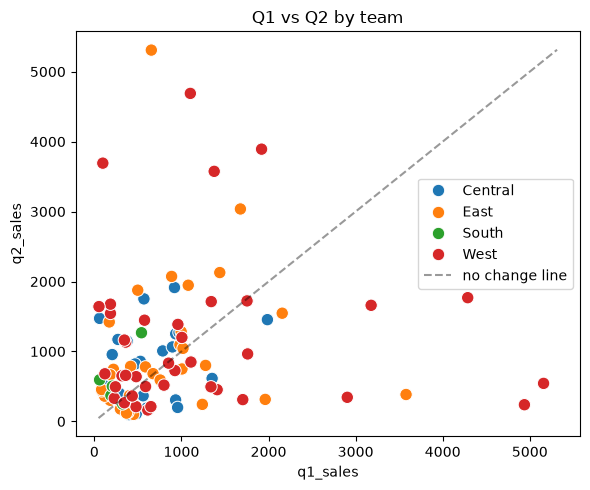

Points above the dashed line grew Q1→Q2.


In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=df, x="q1_sales", y="q2_sales", hue="region", s=80, ax=ax)
lims = [df[["q1_sales", "q2_sales"]].min().min() - 5, df[["q1_sales", "q2_sales"]].max().max() + 5]
ax.plot(lims, lims, "k--", alpha=0.4, label="no change line")
ax.set_title("Q1 vs Q2 by team")
ax.legend()
plt.tight_layout()
plt.show()
print("Points above the dashed line grew Q1→Q2.")


### 5h. Z-score preview — how extreme is TS029?

In [15]:
z = (df["q2_sales"] - stats["mean"]) / stats["std"]
df_z = df.assign(z_score=z.round(2)).sort_values("z_score", ascending=False)
display(df_z[["team", "q2_sales", "z_score"]].head(5))
print("Rule of thumb: |z| > 2 often flagged as unusual (Day 6 builds on this).")


,team,q2_sales,z_score
28,TS029,5308,4.51
88,TS089,4689,3.86
71,TS072,3892,3.03
93,TS094,3692,2.82
76,TS077,3575,2.70


Rule of thumb: |z| > 2 often flagged as unusual (Day 6 builds on this).


## 6. Practice drill — answer without running code first

1. Which region has the **lowest** average Q2?
2. If TS029 is removed, does the **median** change?
3. Write the Excel formula for **median** of Q2.

Run the next cell to confirm your answers.

In [16]:
lowest_avg_region = region["avg_q2"].idxmin()
median_without_13 = df.loc[df["team"] != "TS029", "q2_sales"].median()
print(f"Lowest avg Q2 region: {lowest_avg_region}")
print(f"Median if TS029 removed: {median_without_13:.2f} (unchanged from {stats['median']:.2f})")
print("Excel median formula: =MEDIAN(E2:E101)")


Lowest avg Q2 region: South
Median if TS029 removed: 683.00 (unchanged from 705.00)
Excel median formula: =MEDIAN(E2:E101)


---

## 7. Checkpoint

In [17]:
assert len(df) == LAB_PROFILE["rows"]
assert abs(stats["mean"] - LAB_PROFILE["q2_mean"]) < 0.01
assert abs(stats["median"] - LAB_PROFILE["q2_median"]) < 0.01
assert abs(stats["std"] - LAB_PROFILE["q2_std"]) < 0.01
assert stats["min"] == LAB_PROFILE["q2_min"]
assert stats["max"] == LAB_PROFILE["q2_max"]
assert top_team["team"] == OUTLIER_TEAM
assert region["teams"].sum() == LAB_PROFILE["rows"]
print("Numbers match — you're good.")



Numbers match — you're good.


## Reflection questions

1. When would you report **median** instead of **mean** to leadership?
2. TS029 pulls the mean up — does it change your regional ranking story?
3. Which Excel formula would you use to get regional averages without a pivot table?